# Chebyshev Inequality — Simulation

## What this project proves
Chebyshev's inequality states that for ANY distribution:

P(|X - μ| ≥ kσ) ≤ 1/k²

This notebook verifies this on an Exponential distribution — 
a skewed, non-normal distribution — using 100,000 simulated data points.

## Key finding
The actual probability is always well below the Chebyshev bound,
confirming the inequality holds regardless of distribution shape.

## Libraries used
- NumPy — simulation and calculations
- Matplotlib — visualizations

In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Generate a random variable
# We use exponential distribution - NOT normal
# Why? Because Chebyshev works for ALL distributions, not just normal
# We want to prove it works even on a weird shaped distribution

np.random.seed(42)
data = np.random.exponential(scale=2, size=100000)

# Calculate mean and std
mu = np.mean(data)
sigma = np.std(data)

print(f"Mean (mu): {mu:.4f}")
print(f"Std Dev (sigma): {sigma:.4f}")
print(f"Total data points: {len(data)}")

Mean (mu): 1.9919
Std Dev (sigma): 1.9859
Total data points: 100000


In [3]:
# Test Chebyshev for different values of k
# For each k we check two things:
# 1. Chebyshev BOUND — the theoretical maximum = 1/k²
# 2. ACTUAL probability from our data — count how many points are k*sigma away from mean
# Chebyshev says actual must always be <= bound. Let's verify.

k_values = [1, 1.5, 2, 3, 4, 5]

print(f"{'k':<8} {'Chebyshev Bound':<20} {'Actual Probability':<20} {'Holds?'}")
print("-" * 60)

for k in k_values:
    # Chebyshev upper bound
    bound = 1 / k**2
    
    # Actual probability from data
    actual = np.mean(np.abs(data - mu) >= k * sigma)
    
    # Does the inequality hold?
    holds = "✅ YES" if actual <= bound else "❌ NO"
    
    print(f"{k:<8} {bound:<20.4f} {actual:<20.4f} {holds}")

k        Chebyshev Bound      Actual Probability   Holds?
------------------------------------------------------------
1        1.0000               0.1384               ✅ YES
1.5      0.4444               0.0818               ✅ YES
2        0.2500               0.0493               ✅ YES
3        0.1111               0.0185               ✅ YES
4        0.0625               0.0066               ✅ YES
5        0.0400               0.0025               ✅ YES


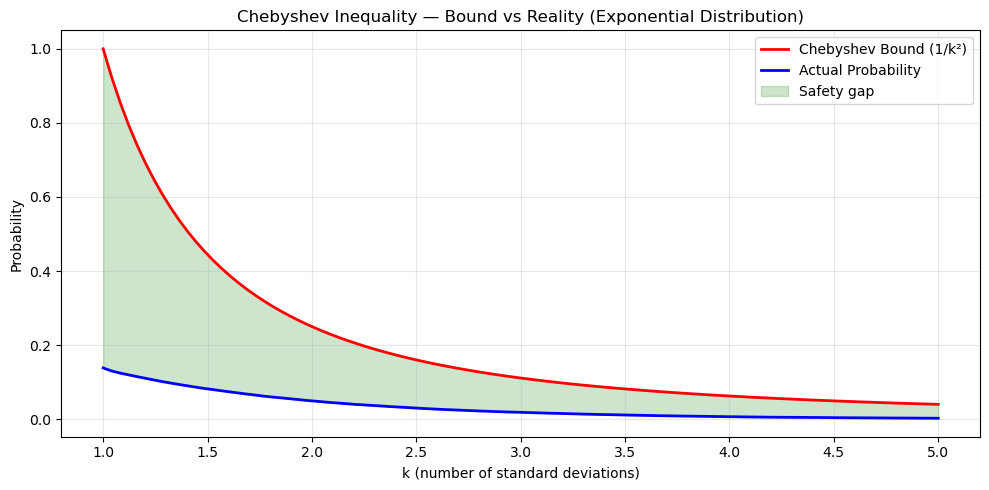

In [4]:
# Plot 1 — Chebyshev Bound vs Actual Probability
# Visual proof that actual is always below the bound

k_values = np.linspace(1, 5, 100)  # 100 values of k between 1 and 5
bound = 1 / k_values**2            # Chebyshev bound for each k
actual = [np.mean(np.abs(data - mu) >= k * sigma) for k in k_values]  # actual probability for each k

plt.figure(figsize=(10, 5))

plt.plot(k_values, bound, color='red', linewidth=2, label='Chebyshev Bound (1/k²)')
plt.plot(k_values, actual, color='blue', linewidth=2, label='Actual Probability')

# Shade the region between them
plt.fill_between(k_values, actual, bound, alpha=0.2, color='green', label='Safety gap')

plt.xlabel('k (number of standard deviations)')
plt.ylabel('Probability')
plt.title('Chebyshev Inequality — Bound vs Reality (Exponential Distribution)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

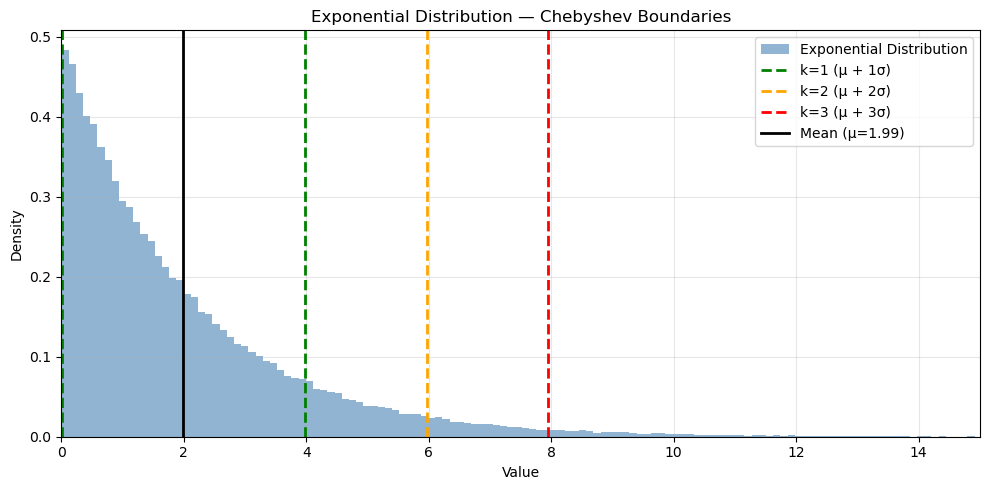

In [5]:
# Plot 2 — Show the actual distribution and mark the k*sigma boundaries
# This makes it visual — where exactly are the extreme points sitting

plt.figure(figsize=(10, 5))

plt.hist(data, bins=200, density=True, color='steelblue', alpha=0.6, label='Exponential Distribution')

# Mark k*sigma boundaries for k = 1, 2, 3
colors = ['green', 'orange', 'red']
for k, color in zip([1, 2, 3], colors):
    lower = mu - k * sigma
    upper = mu + k * sigma
    plt.axvline(upper, color=color, linewidth=2, linestyle='--', label=f'k={k} (μ + {k}σ)')
    if lower > 0:  # exponential can't go below 0
        plt.axvline(lower, color=color, linewidth=2, linestyle='--')

plt.axvline(mu, color='black', linewidth=2, label=f'Mean (μ={mu:.2f})')

plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Exponential Distribution — Chebyshev Boundaries')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 15)
plt.tight_layout()
plt.show()